# ЛАБОРАТОРНАЯ 9
**Тема:** Детекция объектов на медицинских изображениях


**Постановка:** Разработать и обучить модель детекции опухолей мозга
на основе архитектуры YOLO с использованием предобученного backbone.

**Цель:** Реализовать полный пайплайн детекции объектов от загрузки данных до визуализации результатов, включая обучение модели, реализацию NMS.

## Импорты

In [1]:

import os
import random
import numpy as np


import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader


import torchvision.models as models
import torchvision.transforms as T


from PIL import Image


import matplotlib.pyplot as plt
import matplotlib.patches as patches


from datasets import load_dataset


## Пункт 1: Загрузка датасета

Загружаем датасет Brain Tumor. Это набор медицинских изображений с аннотациями для детекции опухолей. Датасет представлен в формате YOLO и включает изображения и текстовые файлы разметки, где каждый bounding box задаётся координатами. Была изучена структура датасета и формат аннотаций для будущего обучения модели детекции объектов.

In [2]:
'''!hf auth login'''

'!hf auth login'

In [3]:
'''dataset = load_dataset("ultralytics/brain-tumor")
print(dataset)'''

'dataset = load_dataset("ultralytics/brain-tumor")\nprint(dataset)'

In [4]:
!wget https://github.com/ultralytics/assets/releases/download/v0.0.0/brain-tumor.zip
!unzip brain-tumor.zip


--2026-01-11 01:23:04--  https://github.com/ultralytics/assets/releases/download/v0.0.0/brain-tumor.zip
Resolving github.com (github.com)... 140.82.114.3
Connecting to github.com (github.com)|140.82.114.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/521807533/da2ef043-cf62-4849-9211-85b761a301a0?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-01-11T02%3A21%3A34Z&rscd=attachment%3B+filename%3Dbrain-tumor.zip&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-01-11T01%3A20%3A57Z&ske=2026-01-11T02%3A21%3A34Z&sks=b&skv=2018-11-09&sig=QVVtnucdcZU8Tzip%2BLMN8dJohs0r8oUHtPp5y1iFE44%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc2ODA5NDg4NCwibmJmIjoxNzY4MDk0NTg0LCJwYXRoIjoicmVsZWFzZWFzc2V0cHJvZHVjdGlvbi5ib

In [5]:
import os
print(os.listdir("/content/labels/train")[:5])
print(os.listdir("/content/images/train")[:5])


['85 (5).txt', '00130_112.txt', '63 (5).txt', '73 (2).txt', '00056_147.txt']
['00096_260.jpg', '79 (3).jpg', '00142_126.jpg', '00130_256.jpg', '00360_114.jpg']


In [6]:
label_file = os.listdir("/content/labels/train")[0]
with open(f"/content/labels/train/{label_file}") as f:
    print(f.read())


1 0.332160 0.295188 0.110329 0.080986


## Пункт 2: Предобученный backbone

В качестве feature extractor был выбран ResNet18
Из архитектуры была удалена классификационная часть (слои average pooling и fully connected)

In [7]:
class ResNetBackbone(nn.Module):
    def __init__(self):
        super().__init__()
        resnet = models.resnet18(pretrained=True)

        # Убираем avgpool и fc
        self.features = nn.Sequential(*list(resnet.children())[:-2])

    def forward(self, x):
        return self.features(x)


## Пункт 3: YOLO модель

In [8]:
'''class SimpleYOLO(nn.Module):
    def __init__(self, backbone, num_classes=1):
        super().__init__()
        self.backbone = backbone

        # Detection head
        self.detection = nn.Conv2d(
            in_channels=2048,
            out_channels=5 + num_classes,
            kernel_size=1
        )

    def forward(self, x):
        features = self.backbone(x)
        predictions = self.detection(features)
        return predictions

model = SimpleYOLO(backbone)'''

'class SimpleYOLO(nn.Module):\n    def __init__(self, backbone, num_classes=1):\n        super().__init__()\n        self.backbone = backbone\n\n        # Detection head\n        self.detection = nn.Conv2d(\n            in_channels=2048,\n            out_channels=5 + num_classes,\n            kernel_size=1\n        )\n\n    def forward(self, x):\n        features = self.backbone(x)\n        predictions = self.detection(features)\n        return predictions\n\nmodel = SimpleYOLO(backbone)'

**ИСПРАВЛЕННЫЙ ВАРИАНТ**

Была реализована упрощённая версия архитектуры YOLOv1, адаптированная под задачу детекции одного класса объектов.
Изображение разбивается на сетку размером S × S, и каждая ячейка сетки предсказывает параметры одного bounding box
Backbone ResNet18 используется для извлечения признаков


In [9]:
class YOLOv1(nn.Module):
    def __init__(self, S=7, B=1, C=1):
        super().__init__()
        self.S = S
        self.B = B
        self.C = C

        self.backbone = ResNetBackbone()

        self.head = nn.Sequential(
            nn.Conv2d(512, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((S, S)),

            nn.Flatten(),
            nn.Linear(256 * S * S, S * S * (5 * B + C))
        )

    def forward(self, x):
        features = self.backbone(x)
        out = self.head(features)

        return out.view(
            -1, self.S, self.S, 5 * self.B + self.C
        )


## Пункт 4: Функция потерь

In [10]:
'''class YOLOLoss(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, preds, targets):

        # Приводим к одной размерности
        preds = preds.permute(0, 2, 3, 1)

        # Простые MSE потери
        loss = nn.MSELoss()(preds, targets)
        return loss

loss_fn = YOLOLoss()'''

'class YOLOLoss(nn.Module):\n    def __init__(self):\n        super().__init__()\n\n    def forward(self, preds, targets):\n\n        # Приводим к одной размерности\n        preds = preds.permute(0, 2, 3, 1)\n\n        # Простые MSE потери\n        loss = nn.MSELoss()(preds, targets)\n        return loss\n\nloss_fn = YOLOLoss()'

**ИСПРАВЛЕННЫЙ ВАРИАНТ**

In [11]:
class YOLOLoss(nn.Module):
    def __init__(self, S=7, lambda_coord=5, lambda_noobj=0.5):
        super().__init__()
        self.S = S
        self.lambda_coord = lambda_coord
        self.lambda_noobj = lambda_noobj
        self.mse = nn.MSELoss(reduction="sum")
        self.bce = nn.BCEWithLogitsLoss(reduction="sum")

    def forward(self, preds, targets):
        """
        preds: [B, S, S, 6]
        targets: [B, S, S, 6]
        """
        obj_mask = targets[..., 4] == 1
        noobj_mask = targets[..., 4] == 0

        # Localization loss
        loc_loss = self.mse(
            preds[obj_mask][..., :4],
            targets[obj_mask][..., :4]
        )

        # Confidence loss
        conf_obj = self.mse(
            preds[obj_mask][..., 4],
            targets[obj_mask][..., 4]
        )

        conf_noobj = self.mse(
            preds[noobj_mask][..., 4],
            targets[noobj_mask][..., 4]
        )

        # Classification loss
        class_loss = self.bce(
            preds[obj_mask][..., 5],
            targets[obj_mask][..., 5]
        )

        total_loss = (
            self.lambda_coord * loc_loss +
            conf_obj +
            self.lambda_noobj * conf_noobj +
            class_loss
        )

        return total_loss


## Пункт 5 Датасет и обучение

In [12]:
'''class BrainTumorDataset(Dataset):
    def __init__(self, split="train"):
        self.split = split
        # Берем данные из загруженного датасета
        self.images = dataset[split]["image"]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]

        # Преобразуем PIL в tensor
        if not isinstance(img, np.ndarray):
            img = np.array(img)

        # Если grayscale, конвертируем в RGB
        if len(img.shape) == 2:
            img = np.stack([img]*3, axis=-1)
        elif img.shape[0] == 3:  # [C, H, W] -> [H, W, C]
            img = img.transpose(1, 2, 0)

        img = Image.fromarray(img).resize((224, 224))
        img = torch.tensor(np.array(img)).permute(2, 0, 1).float() / 255.0

        # Заглушка таргетов (для демо)
        H, W = 7, 7
        targets = torch.zeros((H, W, 6))

        return img, targets

train_dataset = BrainTumorDataset("train")
train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True)'''

'class BrainTumorDataset(Dataset):\n    def __init__(self, split="train"):\n        self.split = split\n        # Берем данные из загруженного датасета\n        self.images = dataset[split]["image"]\n\n    def __len__(self):\n        return len(self.images)\n\n    def __getitem__(self, idx):\n        img = self.images[idx]\n\n        # Преобразуем PIL в tensor\n        if not isinstance(img, np.ndarray):\n            img = np.array(img)\n\n        # Если grayscale, конвертируем в RGB\n        if len(img.shape) == 2:\n            img = np.stack([img]*3, axis=-1)\n        elif img.shape[0] == 3:  # [C, H, W] -> [H, W, C]\n            img = img.transpose(1, 2, 0)\n\n        img = Image.fromarray(img).resize((224, 224))\n        img = torch.tensor(np.array(img)).permute(2, 0, 1).float() / 255.0\n\n        # Заглушка таргетов (для демо)\n        H, W = 7, 7\n        targets = torch.zeros((H, W, 6))\n\n        return img, targets\n\ntrain_dataset = BrainTumorDataset("train")\ntrain_loader = 

**ИСПРАВЛЕННЫЙ ВАРИАНТ**

In [13]:
class BrainTumorDataset(Dataset):
    def __init__(self, img_dir, label_dir, S=7, transform=None):
        self.img_dir = img_dir
        self.label_dir = label_dir
        self.S = S
        self.transform = transform
        self.images = os.listdir(img_dir)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_path = os.path.join(self.img_dir, img_name)
        label_path = os.path.join(
            self.label_dir, img_name.replace(".jpg", ".txt")
        )

        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)

        target = torch.zeros((self.S, self.S, 6))

        if os.path.exists(label_path):
            with open(label_path) as f:
                for line in f.readlines():
                    cls, x, y, w, h = map(float, line.split())

                    i = int(y * self.S)
                    j = int(x * self.S)

                    x_cell = x * self.S - j
                    y_cell = y * self.S - i
                    w_cell = w
                    h_cell = h

                    target[i, j, 0:4] = torch.tensor(
                        [x_cell, y_cell, w_cell, h_cell]
                    )
                    target[i, j, 4] = 1.0
                    target[i, j, 5] = 1.0  # один класс

        return image, target


In [14]:
transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
])


In [15]:
train_dataset = BrainTumorDataset(
    img_dir="/content/images/train",
    label_dir="/content/labels/train",
    S=7,
    transform=transform
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=2
)


**ОБУЧЕНИЕ**

In [16]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = YOLOv1(S=7, B=1, C=1).to(device)
criterion = YOLOLoss(S=7)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [17]:
num_epochs = 5

for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for images, targets in train_loader:
        images = images.to(device)
        targets = targets.to(device)

        preds = model(images)
        loss = criterion(preds, targets)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Loss: {total_loss / len(train_loader):.4f}"
    )


Epoch [1/5] Loss: 20.7164
Epoch [2/5] Loss: 8.5005
Epoch [3/5] Loss: 5.7757
Epoch [4/5] Loss: 4.2440
Epoch [5/5] Loss: 3.3747


## Пункт 6: Non-Maximum Suppression (NMS)

Для устранения избыточных предсказаний был реализован алгоритм Non-Maximum Suppression, основанный на метрике IoU (Intersection over Union).

In [18]:
def box_iou(box1, box2):

    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    inter = max(0, x2 - x1) * max(0, y2 - y1)

    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])

    union = area1 + area2 - inter
    return inter / union if union > 0 else 0


In [19]:
def nms(boxes, scores, iou_threshold=0.5):
    indices = scores.argsort(descending=True)
    keep = []

    while indices.numel() > 0:
        current = indices[0]
        keep.append(current.item())

        if indices.numel() == 1:
            break

        rest = indices[1:]
        ious = torch.tensor([
            box_iou(boxes[current], boxes[i])
            for i in rest
        ])

        indices = rest[ious < iou_threshold]

    return keep


## Пункт 7: Предсказания и визуализация результатов



In [20]:
def decode_predictions(preds, conf_threshold=0.4):
    boxes = []
    scores = []

    S = preds.shape[0]

    for i in range(S):
        for j in range(S):
            x, y, w, h, conf, cls = preds[i, j]
            score = torch.sigmoid(conf) * torch.sigmoid(cls)

            if score > conf_threshold:
                cx = (j + x) / S
                cy = (i + y) / S

                x1 = cx - w / 2
                y1 = cy - h / 2
                x2 = cx + w / 2
                y2 = cy + h / 2

                boxes.append([x1, y1, x2, y2])
                scores.append(score)

    if len(boxes) == 0:
        return None, None

    return torch.tensor(boxes), torch.tensor(scores)


In [21]:
'''model.eval()

img, _ = train_dataset[0]
img_input = img.unsqueeze(0).to(device)

with torch.no_grad():
    preds = model(img_input)[0].cpu()

boxes, scores = decode_predictions(preds, conf_threshold=0.2)

keep = nms(boxes, scores, iou_threshold=0.4)

fig, ax = plt.subplots(1, figsize=(6, 6))
ax.imshow(img.permute(1, 2, 0))

for i in keep:
    x1, y1, x2, y2 = boxes[i]
    rect = patches.Rectangle(
        (x1, y1),
        x2 - x1,
        y2 - y1,
        linewidth=2,
        edgecolor="red",
        facecolor="none"
    )
    ax.add_patch(rect)

ax.set_title("Предсказания после NMS")
ax.axis("off")
plt.show()'''


'model.eval()\n\nimg, _ = train_dataset[0]\nimg_input = img.unsqueeze(0).to(device)\n\nwith torch.no_grad():\n    preds = model(img_input)[0].cpu()\n\nboxes, scores = decode_predictions(preds, conf_threshold=0.2)\n\nkeep = nms(boxes, scores, iou_threshold=0.4)\n\nfig, ax = plt.subplots(1, figsize=(6, 6))\nax.imshow(img.permute(1, 2, 0))\n\nfor i in keep:\n    x1, y1, x2, y2 = boxes[i]\n    rect = patches.Rectangle(\n        (x1, y1),\n        x2 - x1,\n        y2 - y1,\n        linewidth=2,\n        edgecolor="red",\n        facecolor="none"\n    )\n    ax.add_patch(rect)\n\nax.set_title("Предсказания после NMS")\nax.axis("off")\nplt.show()'

**ИСПРАВЛЕННЫЙ ВАРИант**

После обучения модели генерим предсказания на изображениях из датасета.
Для каждого изображения вычисляем боксы и confidence score, после чего выбираем самый уверенный

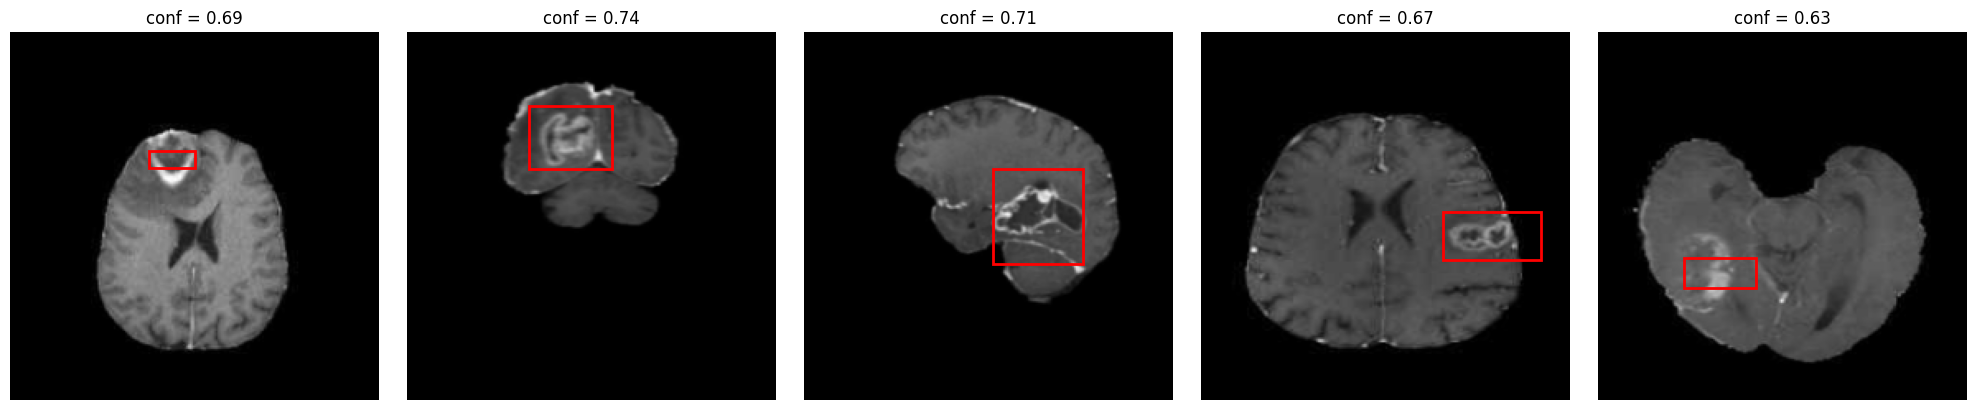

In [26]:
model.eval()

indices = random.sample(range(len(train_dataset)), 5)

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for ax, idx in zip(axes, indices):
    img, _ = train_dataset[idx]
    img_input = img.unsqueeze(0).to(device)

    with torch.no_grad():
        preds = model(img_input)[0].cpu()

    boxes, scores = decode_predictions(preds, conf_threshold=0.0)

    ax.imshow(img.permute(1, 2, 0))

    if boxes is not None:
        best_idx = scores.argmax()
        x1, y1, x2, y2 = boxes[best_idx]

        H, W = img.shape[1:]

        rect = patches.Rectangle(
            (x1 * W, y1 * H),
            (x2 - x1) * W,
            (y2 - y1) * H,
            linewidth=2,
            edgecolor="red",
            facecolor="none"
        )
        ax.add_patch(rect)

        ax.set_title(f"conf = {scores[best_idx]:.2f}")
    else:
        ax.set_title("Объект не найден")

    ax.axis("off")

plt.tight_layout()
plt.show()


Вывод: В ходе лабораторной работы был реализован полный пайплайн детекции с помощью YOLO с предобученным ResNet18. Продемонстрирована работоспособность системы детекции объектов на медицинских изображениях.